<a href="https://colab.research.google.com/github/flutterBeat/festaFestum/blob/main/vendor_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Festa Festum — Vendor Matching Score
**Data Scientist | Minggu 2**

**Bobot scoring:**
- Rating Score       : 40%
- Budget Fit Score   : 35%
- Availability Score : 25%

Output: `vendor_score` (0–100) → dipakai Fullstack untuk sorting `GET /api/v1/vendors`

## 0. Upload Dataset (Jalankan cell ini pertama kali)

In [1]:
from google.colab import files
uploaded = files.upload()  # pilih file vendors.csv
print('File berhasil diupload:', list(uploaded.keys()))

Saving vendors.csv to vendors (1).csv
File berhasil diupload: ['vendors (1).csv']


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import json

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_theme(style='whitegrid')

df = pd.read_csv('vendors.csv')
df['price_mid'] = (df['price_start'] + df['price_end']) / 2
print(f'Dataset loaded: {len(df)} vendor')
df.head()

Dataset loaded: 250 vendor


,vendor_id,vendor_name,category,city,price_start,price_end,style_tags,rating,price_mid
0,EO-001,Mahakarya Planner,Event Organizer,Jakarta,5000000,15000000,"Formal, Mewah, Eksklusif",4.8,10000000.0
1,EO-002,Harmoni Sukses Event,Event Organizer,Bogor,3000000,10000000,"Elegan, Profesional, Terorganisir",4.6,6500000.0
2,EO-003,Brilliance Organizer,Event Organizer,Depok,4000000,12000000,"Modern, Mewah, Detail",4.7,8000000.0
3,EO-004,Grand Festive Co.,Event Organizer,Tangerang,6000000,18000000,"Eksklusif, Grand, Premium",4.9,12000000.0
4,EO-005,Cemerlang Event,Event Organizer,Bekasi,2500000,8000000,"Sederhana, Rapi, Hangat",4.5,5250000.0


## 2. Data Preprocessing

In [3]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())

# Cek tipe data
print('\n=== Tipe Data ===')
print(df.dtypes)

# Statistik deskriptif
print('\n=== Statistik Deskriptif ===')
df[['price_start', 'price_end', 'price_mid', 'rating']].describe()

=== Missing Values ===
vendor_id      0
vendor_name    0
category       0
city           0
price_start    0
price_end      0
style_tags     0
rating         0
price_mid      0
dtype: int64

=== Tipe Data ===
vendor_id       object
vendor_name     object
category        object
city            object
price_start      int64
price_end        int64
style_tags      object
rating         float64
price_mid      float64
dtype: object

=== Statistik Deskriptif ===


,price_start,price_end,price_mid,rating
count,2.500000e+02,2.500000e+02,2.500000e+02,250.000000
mean,1.781160e+06,5.515000e+06,3.648080e+06,4.636800
std,1.532731e+06,4.397869e+06,2.963544e+06,0.159082
min,4.500000e+05,1.650000e+06,1.050000e+06,4.200000
25%,8.000000e+05,2.700000e+06,1.781250e+06,4.500000
50%,1.200000e+06,3.950000e+06,2.550000e+06,4.600000
75%,2.000000e+06,6.000000e+06,4.037500e+06,4.800000
max,8.500000e+06,2.400000e+07,1.625000e+07,4.900000


In [4]:
# Encoding kategori & kota untuk referensi
category_map = {cat: i for i, cat in enumerate(df['category'].unique())}
city_map     = {city: i for i, city in enumerate(df['city'].unique())}

df['category_enc'] = df['category'].map(category_map)
df['city_enc']     = df['city'].map(city_map)

print('Kategori encoding:', category_map)
print('Kota encoding    :', city_map)

Kategori encoding: {'Event Organizer': 0, 'Florist': 1, 'Sewa Jas/Kebaya': 2, 'Hair and MakeUp': 3, 'Fotografer': 4}
Kota encoding    : {'Jakarta': 0, 'Bogor': 1, 'Depok': 2, 'Tangerang': 3, 'Bekasi': 4}


## 3. Vendor Matching Score — Fungsi Utama

In [5]:
def _rating_score(df):
    sc = MinMaxScaler()
    return pd.Series(sc.fit_transform(df[['rating']]).flatten() * 100, index=df.index)

def _budget_score(df, user_budget):
    if user_budget is None:
        sc = MinMaxScaler()
        return pd.Series(sc.fit_transform(-df[['price_mid']].values).flatten() * 100, index=df.index)
    def fit(row):
        if row['price_start'] <= user_budget <= row['price_end']:
            return 100.0
        if user_budget > row['price_end']:
            return 80.0
        r = (row['price_start'] - user_budget) / row['price_start']
        return max(0.0, 100.0 - r * 100)
    return df.apply(fit, axis=1)

def compute_vendor_scores(df, user_budget=None, category=None, city=None, top_n=None):
    d = df.copy()
    if category: d = d[d['category'] == category].copy()
    if city: d = d[d['city'] == city].copy()
    if d.empty: return d
    d['rating_score']       = _rating_score(d)
    d['budget_score']       = _budget_score(d, user_budget)
    d['availability_score'] = 100.0
    d['vendor_score'] = (d['rating_score']*0.40 + d['budget_score']*0.35 + d['availability_score']*0.25).round(2)
    d = d.sort_values('vendor_score', ascending=False).reset_index(drop=True)
    return d.head(top_n) if top_n else d

print('Fungsi siap.')

Fungsi siap.


## 4. Validasi — Simulasi Pencarian User

In [6]:
# Skenario 1: Fotografer, budget Rp 2.000.000
BUDGET = 2_000_000
CAT = 'Fotografer'
r = compute_vendor_scores(df, user_budget=BUDGET, category=CAT)
cols = ['vendor_id','vendor_name','city','price_start','price_end','rating','rating_score','budget_score','vendor_score']
print(f'Top 10 {CAT} | Budget Rp{BUDGET:,}')
print(r[cols].head(10).to_string(index=False))

Top 10 Fotografer | Budget Rp2,000,000
vendor_id            vendor_name      city  price_start  price_end  rating  rating_score  budget_score  vendor_score
   FT-007      Golden Hour Photo   Jakarta      2500000    7000000     4.9         100.0     80.000000         93.00
   FT-001         Kenangan Abadi Tangerang      1500000    4000000     4.8          80.0    100.000000         92.00
   FT-002      Abadi Foto Studio   Jakarta      2000000    5500000     4.8          80.0    100.000000         92.00
   FT-005 Eternal Moments Studio Tangerang      1600000    4500000     4.8          80.0    100.000000         92.00
   FT-011      Karya Lens Studio    Bekasi      1700000    4800000     4.8          80.0    100.000000         92.00
   FT-020  Timeless Photo Studio Tangerang      1800000    5200000     4.8          80.0    100.000000         92.00
   FT-045     Sinema Foto Studio Tangerang      2000000    5700000     4.8          80.0    100.000000         92.00
   FT-027       Arsa Phot

In [7]:
# Skenario 2: Hair and MakeUp, budget Rp 1.000.000
r2 = compute_vendor_scores(df, user_budget=1_000_000, category='Hair and MakeUp')
print('Top 10 Hair and MakeUp | Budget Rp 1.000.000')
print(r2[cols].head(10).to_string(index=False))

Top 10 Hair and MakeUp | Budget Rp 1.000.000
vendor_id           vendor_name    city  price_start  price_end  rating  rating_score  budget_score  vendor_score
   HM-006   Flawless Studio MUA Jakarta       900000    3200000     4.9    100.000000    100.000000        100.00
   HM-008   Haute Beauty Artist   Depok      1100000    4000000     4.9    100.000000     90.909091         96.82
   HM-016   Prestige Beauty MUA Jakarta      1200000    4500000     4.9    100.000000     83.333333         94.17
   HM-002 Cantika Beauty Studio Jakarta       700000    2500000     4.8     83.333333    100.000000         93.33
   HM-017     Queen Glam Studio   Bogor       800000    2900000     4.8     83.333333    100.000000         93.33
   HM-021   Ultima Beauty House Jakarta       950000    3500000     4.8     83.333333    100.000000         93.33
   HM-043      Regal MUA Studio   Depok       900000    3200000     4.8     83.333333    100.000000         93.33
   HM-031   Ethereal Beauty MUA Jakarta    

In [8]:
# Skenario 3: Sewa Jas/Kebaya di Jakarta
r3 = compute_vendor_scores(df, user_budget=1_500_000, category='Sewa Jas/Kebaya', city='Jakarta')
print('Sewa Jas/Kebaya di Jakarta | Budget Rp 1.500.000')
print(r3[cols].head(10).to_string(index=False))

Sewa Jas/Kebaya di Jakarta | Budget Rp 1.500.000
vendor_id           vendor_name    city  price_start  price_end  rating  rating_score  budget_score  vendor_score
   JK-006 Formal Fashion Studio Jakarta      1200000    4000000     4.9    100.000000        100.00        100.00
   JK-016         Pesona Kebaya Jakarta      1300000    4500000     4.9    100.000000        100.00        100.00
   JK-002 Keraton Fashion House Jakarta      1000000    3500000     4.8     66.666667        100.00         86.67
   JK-021 Unggul Fashion Studio Jakarta      1400000    4800000     4.8     66.666667        100.00         86.67
   JK-026  Zamrud Fashion House Jakarta      1600000    5500000     4.8     66.666667         93.75         84.48
   JK-011  Kebaya Cantik Studio Jakarta      1100000    3800000     4.7     33.333333        100.00         73.33
   JK-031   Etnik Fashion House Jakarta      1100000    3700000     4.7     33.333333        100.00         73.33
   JK-036      Javanesse Attire Jakarta

## 5. Visualisasi Top 10 Scoring per Kategori

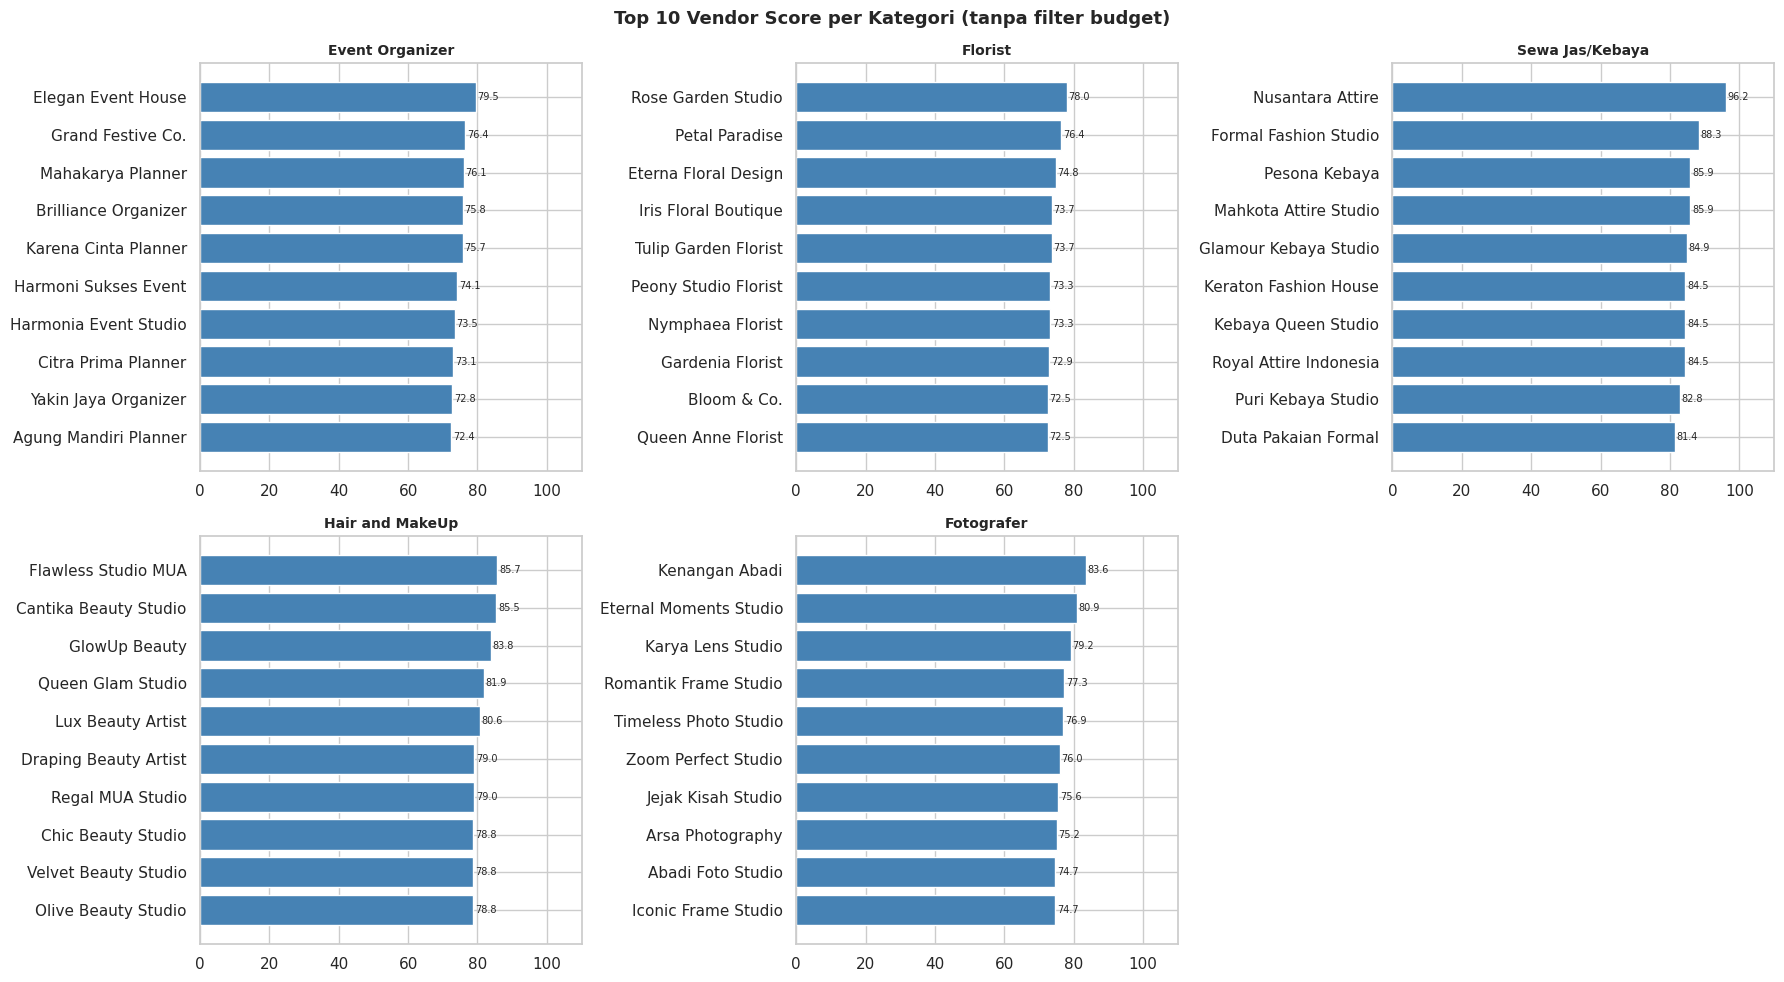

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cats = df['category'].unique()
axes_flat = axes.flatten()

for i, cat in enumerate(cats):
    scored = compute_vendor_scores(df, category=cat).head(10)
    ax = axes_flat[i]
    bars = ax.barh(scored['vendor_name'][::-1], scored['vendor_score'][::-1], color='steelblue')
    ax.set_title(f'{cat}', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 110)
    for bar, s in zip(bars, scored['vendor_score'][::-1]):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{s:.1f}', va='center', fontsize=7)

axes_flat[-1].axis('off')
fig.suptitle('Top 10 Vendor Score per Kategori (tanpa filter budget)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Pengaruh Budget terhadap Skor

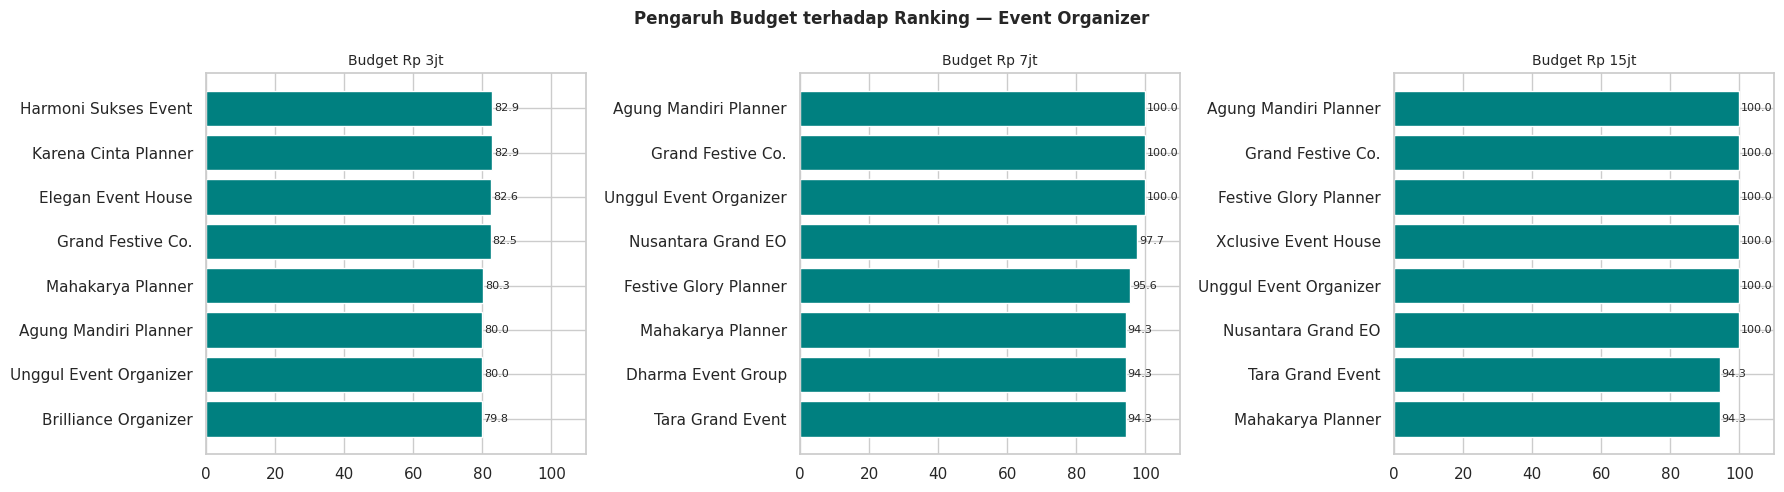

In [10]:
CATEGORY = 'Event Organizer'
budgets = [3_000_000, 7_000_000, 15_000_000]
labels = ['Rp 3jt', 'Rp 7jt', 'Rp 15jt']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, budget, label in zip(axes, budgets, labels):
    top = compute_vendor_scores(df, user_budget=budget, category=CATEGORY).head(8)
    ax.barh(top['vendor_name'][::-1], top['vendor_score'][::-1], color='teal')
    ax.set_title(f'Budget {label}', fontsize=10)
    ax.set_xlim(0, 110)
    for i, (_, row) in enumerate(top[::-1].iterrows()):
        ax.text(row['vendor_score']+0.5, i, f"{row['vendor_score']:.1f}", va='center', fontsize=8)

fig.suptitle(f'Pengaruh Budget terhadap Ranking — {CATEGORY}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Evaluasi — Distribusi Skor Lintas Kategori

In [11]:
print('=== Evaluasi Distribusi Vendor Score per Kategori ===')
for cat in df['category'].unique():
    scored = compute_vendor_scores(df, category=cat)
    print(f"\n{cat}")
    print(f"  Min  : {scored['vendor_score'].min():.1f}")
    print(f"  Max  : {scored['vendor_score'].max():.1f}")
    print(f"  Mean : {scored['vendor_score'].mean():.1f}")
    print(f"  Top  : {scored.iloc[0]['vendor_name']} ({scored.iloc[0]['vendor_score']:.1f})")

=== Evaluasi Distribusi Vendor Score per Kategori ===

Event Organizer
  Min  : 60.0
  Max  : 79.5
  Mean : 69.1
  Top  : Elegan Event House (79.5)

Florist
  Min  : 58.8
  Max  : 78.0
  Mean : 68.2
  Top  : Rose Garden Studio (78.0)

Sewa Jas/Kebaya
  Min  : 58.8
  Max  : 96.2
  Mean : 75.1
  Top  : Nusantara Attire (96.2)

Hair and MakeUp
  Min  : 60.0
  Max  : 85.7
  Mean : 74.6
  Top  : Flawless Studio MUA (85.7)

Fotografer
  Min  : 59.6
  Max  : 83.6
  Mean : 70.8
  Top  : Kenangan Abadi (83.6)


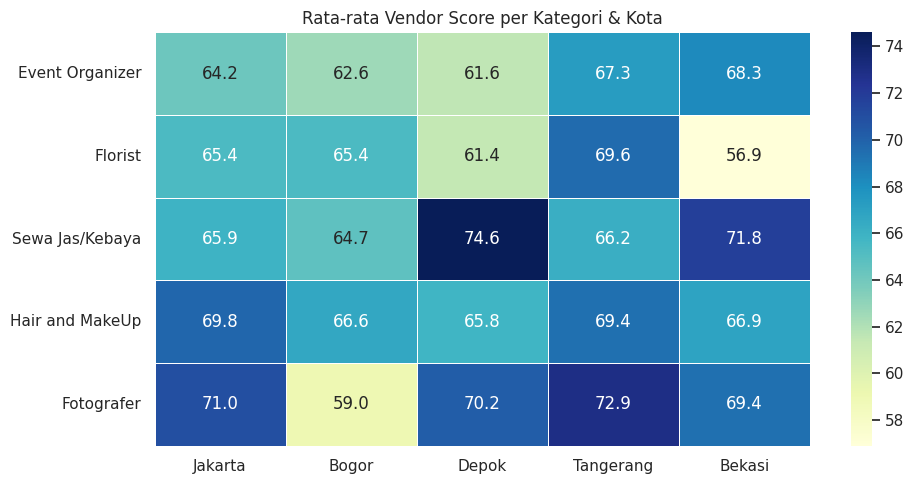

In [12]:
import warnings; warnings.filterwarnings('ignore')
pivot = pd.DataFrame()
for cat in df['category'].unique():
    for city in df['city'].unique():
        row = compute_vendor_scores(df, category=cat, city=city)
        if not row.empty:
            pivot.loc[cat, city] = round(row['vendor_score'].mean(), 1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot.astype(float), annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Rata-rata Vendor Score per Kategori & Kota', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Export JSON untuk Fullstack

Output siap dikonsumsi endpoint `GET /api/v1/vendors`.

In [13]:
def to_api_json(df_scored):
    cols = ['vendor_id','vendor_name','category','city','price_start','price_end','style_tags','rating','vendor_score']
    return df_scored[cols].to_dict(orient='records')

sample = to_api_json(compute_vendor_scores(df, user_budget=2_000_000, category='Fotografer', top_n=5))
print(json.dumps(sample, indent=2, ensure_ascii=False))

[
  {
    "vendor_id": "FT-007",
    "vendor_name": "Golden Hour Photo",
    "category": "Fotografer",
    "city": "Jakarta",
    "price_start": 2500000,
    "price_end": 7000000,
    "style_tags": "Golden Hour, Warm, Cinematic",
    "rating": 4.9,
    "vendor_score": 93.0
  },
  {
    "vendor_id": "FT-001",
    "vendor_name": "Kenangan Abadi",
    "category": "Fotografer",
    "city": "Tangerang",
    "price_start": 1500000,
    "price_end": 4000000,
    "style_tags": "Cinematic, Vintage, Jurnalistik",
    "rating": 4.8,
    "vendor_score": 92.0
  },
  {
    "vendor_id": "FT-002",
    "vendor_name": "Abadi Foto Studio",
    "category": "Fotografer",
    "city": "Jakarta",
    "price_start": 2000000,
    "price_end": 5500000,
    "style_tags": "Formal, Profesional, Eksklusif",
    "rating": 4.8,
    "vendor_score": 92.0
  },
  {
    "vendor_id": "FT-005",
    "vendor_name": "Eternal Moments Studio",
    "category": "Fotografer",
    "city": "Tangerang",
    "price_start": 1600000,
    

---
## Catatan Integrasi

| Output | Dipakai Oleh | Keterangan |
|---|---|---|
| `vendor_scoring.py` | Fullstack, AI Engineer | Modul Python siap di-import |
| `to_api_json()` | Fullstack | Format JSON untuk `GET /api/v1/vendors` |
| Chart cell 5–7 | PM | Materi slide Tech Secret Sauce |

**Catatan Fullstack:** `availability_score` placeholder 100 — ganti dengan query tabel `Vendor_Schedules` di produksi.

**Catatan AI Engineer:** Kolom `rating_score`, `budget_score`, `vendor_score` bisa dipakai sebagai fitur input model rekomendasi di `/api/v1/ai/recommend`.